# Dataset Preprocessing

This notebook covers data analysis and necessary dataset preprocessing before implementing Apriori Algorithm.

------------------------------------

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Do not show warning messages while execution
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load dataset
df = pd.read_excel('../../data/raw/Shopping-cart-dataset.xlsx')

# Analyze dataset dimensions and preview top columns
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn Types: \n{df.dtypes}")
print(f"\nPreview:\n{df.head(10).to_string()}")


Shape: 50747 rows x 8 columns

Column Types: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Preview:
  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   2.55      17850.0  United Kingdom
1  536365     71053                  WHITE METAL LANTERN         6 2010-12-01 08:26:00   3.39      17850.0  United Kingdom
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00   2.75      17850.0  United Kingdom
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00   3.39      17850.0  United Kingdom
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-

     Column  Missing Count  Missing %
    Invoice              0   0.000000
  StockCode              0   0.000000
Description            143   0.281790
   Quantity              0   0.000000
InvoiceDate              0   0.000000
      Price              0   0.000000
Customer ID          18384  36.226772
    Country              0   0.000000


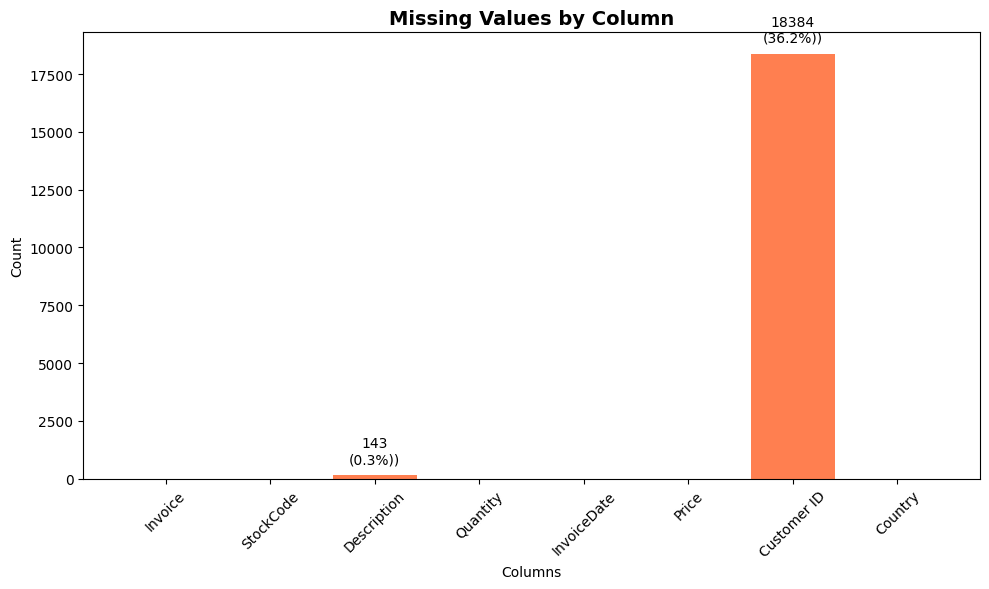

Image saved in /apriori/data/visuals/missing_data_analysis.png


In [4]:
# Visualize and analyze all initially observed missing data from the dataset

missing_data_null = df.isnull().sum()
missing_data_percent = (missing_data_null / len(df)) * 100

# Configure and display missing data table
missing_summary = pd.DataFrame({
    'Column': missing_data_null.index,
    'Missing Count': missing_data_null.values,
    'Missing %': missing_data_percent.values
})

print(missing_summary.to_string(index=False))

# Create visualization table
plt.figure(figsize=(10,6))
plt.bar(missing_summary['Column'], missing_summary['Missing Count'], color='coral')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(missing_summary['Missing Count']):
    if v > 0:
        plt.text(i, v + len(df)*0.01, f'{v}\n({missing_data_percent.iloc[i]:.1f}%))', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../../data/visuals/missing_data_analysis.png', dpi=150)
plt.show()

print(f"Image saved in /apriori/data/visuals/missing_data_analysis.png")

In [5]:
# Comprehensive Missing Data Check from Feature == 'Description' -- Item Column
null_values = df['Description'].isnull().sum()
print(f"null count: {null_values}")

emptry_strings = (df['Description'] == '').sum()
print(f"empty strings count: {emptry_strings}")

whitespaces = df['Description'].astype(str).str.strip().eq('').sum()
print(f"whitespaces count: {whitespaces}")

nan_strings = df['Description'].astype(str).str.lower().eq('nan').sum()
print(f"nan strings count: {nan_strings}")

null_strings = df['Description'].astype(str).str.lower().eq('null').sum()
print(f"null strings count: {null_strings}")

none_values = (df['Description'] == None).sum()
print(f"none values count: {none_values}")

special_chars = (df['Description'] == '?').sum()
print(f"special characters count: {special_chars}")

# Create placeholder for missing values in ALL types
description_str = df['Description'].astype(str)
missing_ph = (
    df['Description'].isnull() |
    (description_str == '') |
    (description_str.str.strip() == '') |
    (description_str.str.lower() == 'nan') |
    (description_str.str.lower() == 'null') | 
    (df['Description'] == None) | 
    (df['Description'] == '?')
)

# Percentage of Missing Data
# null_values and nan_strings provide similar rows tagged as missing, thus only 2 features are summed up
total_missing = missing_ph.sum()
print(f"\nTotal Missing 'Description' Data: {total_missing}")
print(f"% of Missing Data: {total_missing/len(df)*100:.2f}%")

null count: 143
empty strings count: 0
whitespaces count: 0
nan strings count: 143
null strings count: 0
none values count: 0
special characters count: 4

Total Missing 'Description' Data: 147
% of Missing Data: 0.29%


In [6]:
# Preview missing data samples for Description column
if total_missing > 0:
    missing_examples = df[missing_ph].head(10)
    print(missing_examples[['Invoice','Description','Price','InvoiceDate']].to_string())
else:
    print(f"\n No Missing/Empty Values found in Description column")

     Invoice Description  Price         InvoiceDate
622   536414         NaN    0.0 2010-12-01 11:52:00
1510  536545         NaN    0.0 2010-12-01 14:32:00
1985  536547         NaN    0.0 2010-12-01 14:33:00
1986  536546         NaN    0.0 2010-12-01 14:33:00
2022  536552         NaN    0.0 2010-12-01 14:34:00
2023  536549         NaN    0.0 2010-12-01 14:34:00
2024  536550         NaN    0.0 2010-12-01 14:34:00
2025  536553         NaN    0.0 2010-12-01 14:35:00
2026  536554         NaN    0.0 2010-12-01 14:35:00
2406  536589         NaN    0.0 2010-12-01 16:50:00


In [7]:
# Handle ALL forms of Missing data for Description column

shape_before = df.shape
row_count_before = len(df)

# Normalize description column (convert Description to string and strip whitespace)
df['Description'] = df['Description'].astype(str).str.strip()

# Replace all forms of missing values with NaN
missing_values = ['?', '', 'nan', 'NaN', 'NAN', 'null', 'NULL', 'Null', 'none', 'None', 'NONE']
df['Description'] = df['Description'].replace(missing_values, np.nan)

null_rows = df['Description'].isnull().sum()
print(f"Rows with null or empty Description: {null_rows}")

# Proceed with dropping missing/special chars value from the dataframe
df = df.dropna(subset=['Description'])
row_count_after = len(df)

print(f"\n- Row Count Before: {row_count_before}")
print(f"- Row Count After: {row_count_after}")
print(f"- Row Count Removed: {row_count_before - row_count_after}")
print(f"- Percentage Romoved: {(row_count_before - row_count_after)/row_count_before*100:.2f}%")

shape_current = df.shape

print(f"Dataframe shape prior: {shape_before}")
print(f"Datafram shape after: {shape_current}")

Rows with null or empty Description: 147

- Row Count Before: 50747
- Row Count After: 50600
- Row Count Removed: 147
- Percentage Romoved: 0.29%
Dataframe shape prior: (50747, 8)
Datafram shape after: (50600, 8)


In [8]:
# Verficication of no missing values for Description column

print(f"Check for remaining missing values for Description column:")
remaining_null = df['Description'].isnull().sum()
remaining_empty = (df['Description'] == '').sum()
remaining_whitespace = df['Description'].str.strip().eq('').sum()
remaining_special_chars = (df['Description'] == '?').sum()

print(f"Remaining null values: {remaining_null}")
print(f"Remaining empty strings: {remaining_empty}")
print(f"Remaining whitespaces: {remaining_whitespace}")
print(f"Remaining special chars: {remaining_special_chars}")

Check for remaining missing values for Description column:
Remaining null values: 0
Remaining empty strings: 0
Remaining whitespaces: 0
Remaining special chars: 0


In [9]:
# Check and handle missing values for other Features
missing_invoice = df['Invoice'].isnull().sum()
missing_stock_code = df['StockCode'].isnull().sum()
missing_quantity = df['Quantity'].isnull().sum()
missing_invoice_date = df['InvoiceDate'].isnull().sum()
missing_price = df['Price'].isnull().sum()
missing_customer_id = df['Customer ID'].isnull().sum()
missing_country = df['Country'].isnull().sum()

print(f"Checking and handling missing data for other columns:")
print(f"Missing Invoice Count: {missing_invoice}")
print(f"Missing StockCode Count: {missing_stock_code}")
print(f"Missing Quantity Count: {missing_quantity}")
print(f"Missing InvoiceDate Count: {missing_invoice_date}")
print(f"Missing Price Count: {missing_price}")
print(f"Missing Customer ID Count: {missing_customer_id}")
print(f"Missing Country: {missing_country}")

# Drop tables that are unnecessary to the task: item association, to reduce dimensionality 
# 1. Customer ID: instead of handling missing data, since there no requirement for personalized recommendation, drop the column
# 2. Country: no requirement for geographical analysis
# 3. Price: no revenue lift calculation requirement

print(f"\nDropping unnecessary columns:")
print(f"Dataframe prior feature drops: {shape_current}")

df = df.drop(columns=['Customer ID', 'Price', 'Country'])
shape_drop = df.shape

print(f"Dataframe prior after drops: {shape_drop}")
print(f"Columns: Customer ID, Price, and Country are dropped!")



Checking and handling missing data for other columns:
Missing Invoice Count: 0
Missing StockCode Count: 0
Missing Quantity Count: 0
Missing InvoiceDate Count: 0
Missing Price Count: 0
Missing Customer ID Count: 18237
Missing Country: 0

Dropping unnecessary columns:
Dataframe prior feature drops: (50600, 8)
Dataframe prior after drops: (50600, 5)
Columns: Customer ID, Price, and Country are dropped!


In [ ]:
# Data type validation and conversion

print(f"Validating data types and converting to proper types")
print(f"Current data types: \n{df.dtypes}")

# Convert Invoice to string to preserve leading zero digits
df['Invoice'] = df['Invoice'].astype(str)

# Convert InvoiceData to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Clean Description by removing lead/trail whitespaces
df['Description'] = df['Description'].str.strip()

print(f"\nData types after Conversions: \n{df.dtypes}")



Validating data types and converting to proper types
Current data types: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
dtype: object

Data types after Conversions: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
dtype: object


In [11]:
# Invalid and outlier data analysis
# 1. Negative values for quantities colimn
# 2. Ouliers that can skew frequency analysis

# Check for negative values in Quantity feature
negative_qty = (df['Quantity'] < 0).sum()
negative_qty_ph = (df['Quantity'] < 0)          # placeholder for negative quantities
print(f"Negative Quantities Count: {negative_qty}")
print(f"Negative Quantities %: {negative_qty/len(df)*100:.2f}%")

print("\n Quantity Statistics:")
print(df['Quantity'].describe())

if negative_qty > 0:
    negative_qty_example = df[negative_qty_ph].head(10)
    print(negative_qty_example[['Invoice','Description','Quantity']].to_string())
else:
    print(f"\n No Negative Values found in Quantity column")



Negative Quantities Count: 931
Negative Quantities %: 1.84%

 Quantity Statistics:
count    50600.000000
mean         8.317075
std         54.692815
min      -9360.000000
25%          1.000000
50%          2.000000
75%          8.000000
max       2880.000000
Name: Quantity, dtype: float64
     Invoice                       Description  Quantity
141  C536379                          Discount        -1
154  C536383   SET OF 3 COLOURED  FLYING DUCKS        -1
235  C536391     PLASTERS IN TIN CIRCUS PARADE       -12
236  C536391   PACK OF 12 PINK PAISLEY TISSUES       -24
237  C536391   PACK OF 12 BLUE PAISLEY TISSUES       -24
238  C536391  PACK OF 12 RED RETROSPOT TISSUES       -24
239  C536391       CHICK GREY HOT WATER BOTTLE       -12
240  C536391   PLASTERS IN TIN VINTAGE PAISLEY       -12
241  C536391            PLASTERS IN TIN SKULLS       -24
937  C536506          JAM MAKING SET WITH JARS        -6


Image saved in /apriori/data/visuals/quantity_outlier_analysis.png


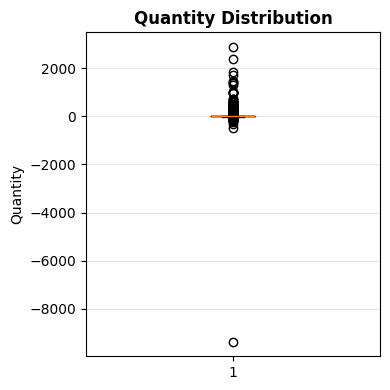

In [12]:
# Visualize outliers
plt.figure(figsize=(4,4))

# Quantity distribution
plt.boxplot(df['Quantity'])
plt.title('Quantity Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Quantity')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/visuals/quantity_outlier_analysis.png', dpi=150)
plt.show

print(f"Image saved in /apriori/data/visuals/quantity_outlier_analysis.png")

In [13]:
# Handle outliers/negative values for Quantity column

print("Removing negative quantities: ")
rows_with_outliers = len(df)
df = df[df['Quantity'] > 0]
print(f"- Rows removed: {rows_with_outliers - len(df)}")
print(f"\nUpdated dataframe dimensions: {df.shape}")


Removing negative quantities: 
- Rows removed: 931

Updated dataframe dimensions: (49669, 5)


In [14]:
# Item Description Cleaning and Normalization

# Inconsistency checking for string casing
print("\nCase Checking Analysis: ")
uppercase_count = df['Description'].str.isupper().sum()
lowercase_count = df['Description'].str.islower().sum()
mixed_case_count = len(df) - uppercase_count - lowercase_count

print(f"- Uppercase Count: {uppercase_count}")
print(f"- Lowercase Count: {lowercase_count}")
print(f"- Mixed Case Count: {mixed_case_count}")

# Unique item count
unique_items = df['Description'].nunique()
print(f"\nUnique items: {unique_items}")

# Frequent items
print(f"\nTop 10 Most Frequent Items: ")
top_items = df['Description'].value_counts().head(10)
for item, count in top_items.items():
    print(f"  {item[:50]:<50} | {count:>5}")



Case Checking Analysis: 
- Uppercase Count: 49491
- Lowercase Count: 5
- Mixed Case Count: 173

Unique items: 2795

Top 10 Most Frequent Items: 
  WHITE HANGING HEART T-LIGHT HOLDER                 |   282
  REGENCY CAKESTAND 3 TIER                           |   210
  HAND WARMER BABUSHKA DESIGN                        |   189
  PAPER CHAIN KIT 50'S CHRISTMAS                     |   178
  SCOTTIE DOG HOT WATER BOTTLE                       |   178
  HEART OF WICKER SMALL                              |   175
  CHOCOLATE HOT WATER BOTTLE                         |   169
  JAM MAKING SET PRINTED                             |   162
  JUMBO BAG RED RETROSPOT                            |   149
  HOT WATER BOTTLE BABUSHKA                          |   147


In [15]:
# Normalize descriptions

print("Cleaning / normalizing Description column: ")
unique_before = df['Description'].nunique()

# Convert all Description values to uppercase for consistency
df['Description'] = df['Description'].str.upper()

# Remove extra whitespace
df['Description'] = df['Description'].str.replace(r'\s+', ' ', regex=True).str.strip()

unique_after = df['Description'].nunique()

print(f"\nUnique items before: {unique_before}")
print(f"Unique items after: {unique_after}")
print(f"Items merged: {unique_before - unique_after}")

Cleaning / normalizing Description column: 

Unique items before: 2795
Unique items after: 2793
Items merged: 2


Irrelevant item analysis: 
  POST items: 78
  C2 items: 11
  DOT items: 63
  M items: 36
  BANK CHARGES items: 1
  AMAZONFEE items: 1
Total irrelevant items: 190
(49669, 5)

Item frequency distribution: 
- Item Frequency = 1: 339
- Item Frequency = 2-5: 636
- Item Frequency > 100: 39


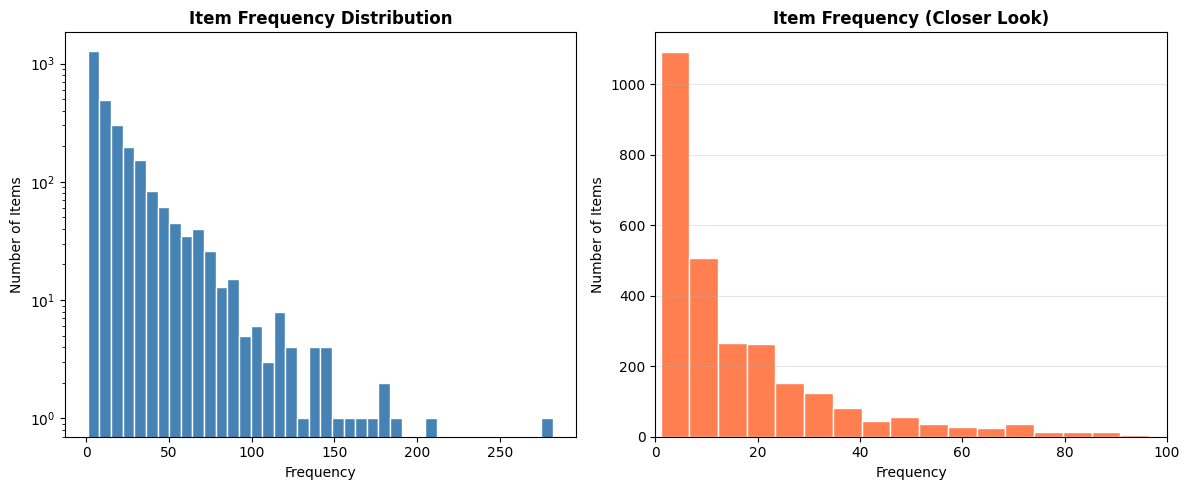

Row count before removing irrelevant items: 49669
Row count after removing irrelevant items: 49479

Image saved in /apriori/data/visuals/item_frequency_distribution.png


In [16]:
# Irrelevant item analysis 
# In POS systems, operational and service transactions are listed as Items in the Description column
# Example: Bank Charges, Discount, Adjustments, Postage, Etc // these must be removed to provide meaningful output

print(f"Irrelevant item analysis: ")

# Referring from StockCode column, operational and service transactions are as follows:
irrelevant_keywords = ['POST', 'C2', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'D', 'S']
total_matched = 0
for keyword in irrelevant_keywords:
    matched = (df['StockCode'] == keyword).sum()
    if matched > 0:
        print(f"  {keyword} items: {matched}")
        total_matched += matched

print(f"Total irrelevant items: {total_matched}")

print(df.shape)

# Analysis for item frequency distribution
item_counts = df['Description'].value_counts()
print(f"\nItem frequency distribution: ")
print(f"- Item Frequency = 1: {(item_counts == 1).sum()}")
print(f"- Item Frequency = 2-5: {((item_counts >= 2) & (item_counts <= 5)).sum()}")
print(f"- Item Frequency > 100: {(item_counts > 100).sum()}")

# Visualize frequency distribution
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.hist(item_counts.values, bins=40, color='steelblue', edgecolor='white')
plt.title('Item Frequency Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Number of Items')
plt.yscale('log')

plt.subplot(1,2,2)
plt.hist(item_counts.values, bins=50, color='coral', edgecolor='white')
plt.title('Item Frequency (Closer Look)', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Number of Items')
plt.xlim(0,100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/visuals/item_frequency_distribution.png', dpi=150)
plt.show()

# Drop all irrelevant rows at once
print(f"Row count before removing irrelevant items: {len(df)}")
df = df[~df['StockCode'].isin(irrelevant_keywords)]
print(f"Row count after removing irrelevant items: {len(df)}")

print(f"\nImage saved in /apriori/data/visuals/item_frequency_distribution.png")


In [17]:
# Filter items based on frequency thresholds

rows_before_thresholds = len(df)
print("Filtering items by Frequency: ")

# Calculate total transaction count for threshold based on Invoice column (heuristic rule)
transaction_count = df['Invoice'].nunique()
min_support_threshold = int(0.001 * transaction_count) #0.1% of transactions
max_support_threshold = int(0.50 * transaction_count) #50% of transactions

print("\nThresholds: ")
print(f"- Minimum support {min_support_threshold} occurences")
print(f"- Maximum support {max_support_threshold} occurences")

# Get valid items
item_counts = df['Description'].value_counts()
valid_items = item_counts[
    (item_counts >= min_support_threshold) &
    (item_counts <= max_support_threshold)
].index

print(f"\nItems meeting criteria: {len(valid_items)} of {len(item_counts)}")

# Filter dataframe
df = df[df['Description'].isin(valid_items)]

print(f"Rows removed: {rows_before_thresholds - len(df)}")
print(f"Updated dataset shape: {df.shape}")

Filtering items by Frequency: 

Thresholds: 
- Minimum support 1 occurences
- Maximum support 901 occurences

Items meeting criteria: 2788 of 2788
Rows removed: 0
Updated dataset shape: (49479, 5)


In [18]:
# Preview transactions format for Apriori

print(f"Create Transaction Format: ")

transactions = []
transaction_ids = []

# Group items by Invoice number maintaining on non-empty transactions
for invoice, group in df.groupby('Invoice'):
    items = set(group['Description'].unique())
    if len(items) > 0:
        transactions.append(items)
        transaction_ids.append(invoice)

# Count total transactions from the dataset
print(f"Transactions Summary: ")
print(f"- Total Transaction Count: {len(transactions)}")

# Provide transaction statistics
transaction_sizes = [len(t) for t in transactions]
print(f"\nTransaction Size Statistics")
print(f"- Mean items per transaction: {np.mean(transaction_sizes):.2f}")
print(f"- Median items per transaction: {np.median(transaction_sizes):.2f}")
print(f"- Min items: {min(transaction_sizes)}")
print(f"- Max items: {max(transaction_sizes)}")

# Show sample transactions
print(f"\nSample Transactions: ")
for i in range(min(5, len(transactions))):
    item_list = list(transactions[i])
    print(f" Transaction {transaction_ids[i]}: {item_list[:5]}: {''if len(item_list) > 5 else ''}({len(item_list)} items)")

Create Transaction Format: 
Transactions Summary: 
- Total Transaction Count: 1802

Transaction Size Statistics
- Mean items per transaction: 26.85
- Median items per transaction: 14.00
- Min items: 1
- Max items: 672

Sample Transactions: 
 Transaction 536365: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'CREAM CUPID HEARTS COAT HANGER']: (7 items)
 Transaction 536366: ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK']: (2 items)
 Transaction 536367: ['BOX OF 6 ASSORTED COLOUR TEASPOONS', 'DOORMAT NEW ENGLAND', 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'BOX OF VINTAGE ALPHABET BLOCKS', 'LOVE BUILDING BLOCK WORD']: (12 items)
 Transaction 536368: ['BLUE COAT RACK PARIS FASHION', 'RED COAT RACK PARIS FASHION', 'JAM MAKING SET WITH JARS', 'YELLOW COAT RACK PARIS FASHION']: (4 items)
 Transaction 536369: ['BATH BUILDING BLOCK WORD']: (1 items)


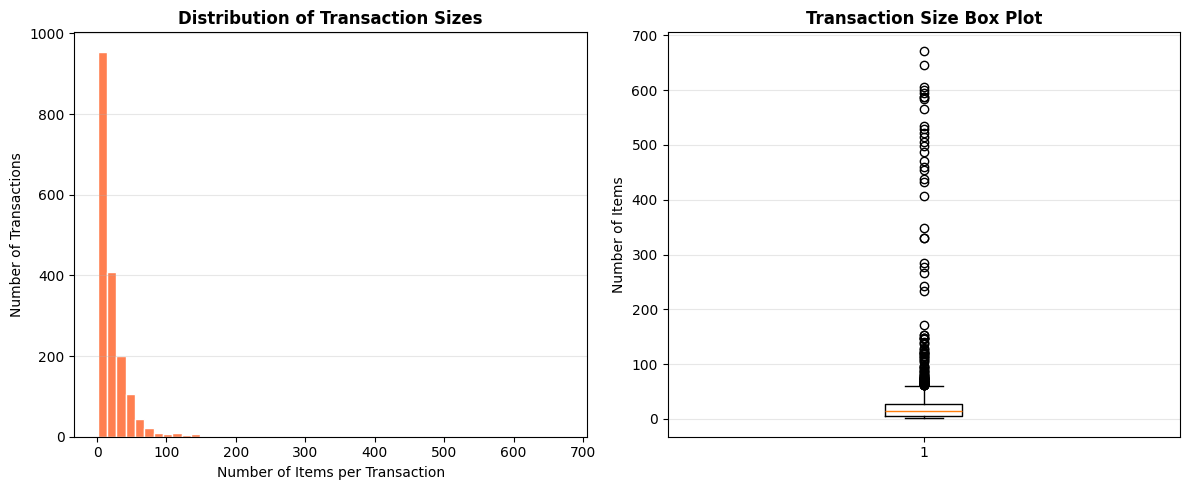


Image saved in /apriori/data/visuals/transaction_size_distribution.png


In [19]:
# Visualize transaction size distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(transaction_sizes, bins=50, color='coral', edgecolor='white')
plt.title('Distribution of Transaction Sizes', fontsize=12, fontweight='bold')
plt.xlabel('Number of Items per Transaction')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1,2,2)
plt.boxplot(transaction_sizes)
plt.title('Transaction Size Box Plot', fontsize=12, fontweight='bold')
plt.ylabel('Number of Items')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/visuals/transaction_size_distribution.png', dpi=150)
plt.show()

print(f"\nImage saved in /apriori/data/visuals/transaction_size_distribution.png")

In [20]:
# Save preprocessed data

# Save as csv
print("Saving preprocessed dataset: ")
df.to_csv("../../data/processed/preprocessed_data.csv")
print(f"- Saved: /apriori/data/processed/preprocessed_data.csv")

# Save as pickle file
import pickle
with open('../../data/processed/transaction.pkl', 'wb') as f:
    pickle.dump(transactions,f)
print(f"- Saved: /apriori/data/processed/transactions.pkl")

print(f"- Prepocessed Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Saving preprocessed dataset: 
- Saved: /apriori/data/processed/preprocessed_data.csv
- Saved: /apriori/data/processed/transactions.pkl
- Prepocessed Dataset Shape: 49479 rows x 5 columns
